# argentina.geo.shapes — Mapas de Argentina

Recorrido **usando el paquete** para armar mapas reales del país.

Las geometrías vienen del WFS oficial del [IGN](https://www.ign.gob.ar/NuestrasActividades/InformacionGeoespacial/CapasSIG). La primera vez se bajan (~45 MB provincias, ~57 MB departamentos), después quedan cacheadas en `~/.cache/argentina/shapes/`.

## 1. Setup

In [1]:
import argentina as arg

import matplotlib.pyplot as plt

print(f"argentina v{arg.__version__}")

argentina v0.0.9


## 2. Argentina al completo

Mapa básico de las 24 provincias.

In [2]:
gdf = arg.geo.shapes.provincias()
print(f"{len(gdf)} provincias, CRS={gdf.crs.name}")
gdf[['in1', 'nam', 'fna']].head()

24 provincias, CRS=WGS 84


,in1,nam,fna
0,02,Ciudad Autónoma de Buenos Aires,Ciudad Autónoma de Buenos Aires
1,74,San Luis,Provincia de San Luis
2,82,Santa Fe,Provincia de Santa Fe
3,90,Tucumán,Provincia de Tucumán
4,38,Jujuy,Provincia de Jujuy


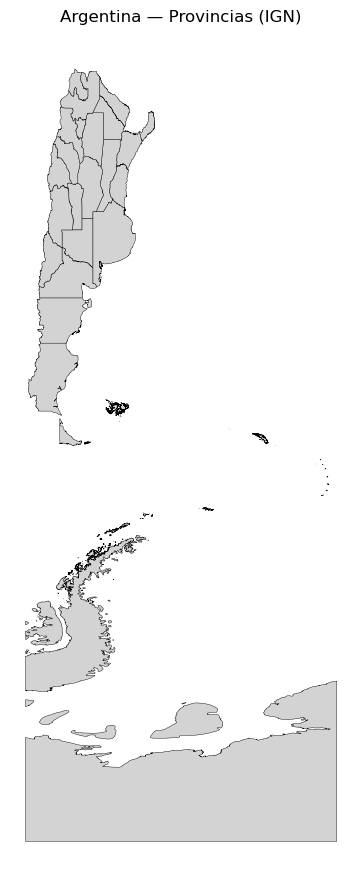

In [3]:
fig, ax = plt.subplots(figsize=(6, 9))
gdf.plot(ax=ax, edgecolor='black', facecolor='lightgray', linewidth=0.3)
ax.set_title('Argentina — Provincias (IGN)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Coloreado por región

Cruzamos la geometría con `argentina.provincias` por código INDEC (`in1`) para enriquecer cada polígono con su región.

In [4]:
gdf['region'] = gdf['in1'].apply(lambda c: arg.provincias.lookup(c).region)
gdf[['nam', 'in1', 'region']].sort_values('region').head(10)

,nam,in1,region
0,Ciudad Autónoma de Buenos Aires,02,CABA
18,Mendoza,50,Cuyo
19,San Juan,70,Cuyo
1,San Luis,74,Cuyo
9,Formosa,34,NEA
17,Corrientes,18,NEA
12,Misiones,54,NEA
8,Chaco,22,NEA
13,Salta,66,NOA
21,La Rioja,46,NOA


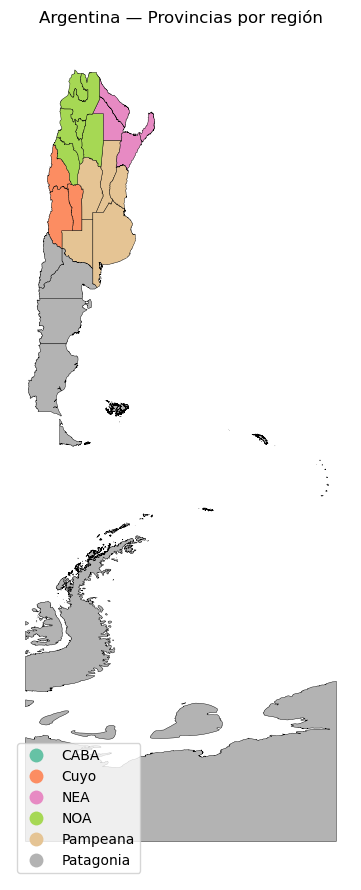

In [5]:
fig, ax = plt.subplots(figsize=(7, 9))
gdf.plot(
    ax=ax,
    column='region',
    cmap='Set2',
    legend=True,
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={'loc': 'lower left', 'frameon': True},
)
ax.set_title('Argentina — Provincias por región')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 4. Mapa con etiquetas

Anotamos cada provincia con su nombre corto en el centroide del polígono.

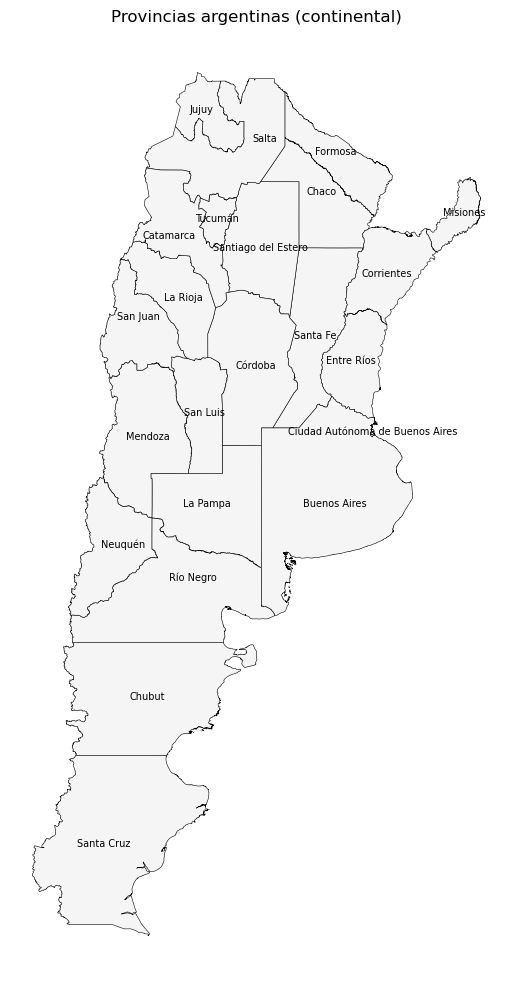

In [6]:
# Solo provincias continentales para que las etiquetas no se vean apretadas
continental = gdf[gdf['nam'] != 'Tierra del Fuego, Antártida e Islas del Atlántico Sur'].copy()

fig, ax = plt.subplots(figsize=(8, 10))
continental.plot(ax=ax, edgecolor='black', facecolor='whitesmoke', linewidth=0.4)

for _, row in continental.iterrows():
    c = row.geometry.representative_point()
    ax.annotate(
        row['nam'],
        xy=(c.x, c.y),
        ha='center',
        fontsize=7,
    )

ax.set_title('Provincias argentinas (continental)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 5. Zoom a una región: Patagonia

Filtramos las provincias patagónicas usando la columna que armamos.

In [7]:
patagonia = gdf[gdf['region'] == 'Patagonia']
list(patagonia['nam'])

['Chubut',
 'Río Negro',
 'Tierra del Fuego, Antártida e Islas del Atlántico Sur',
 'Neuquén',
 'Santa Cruz']

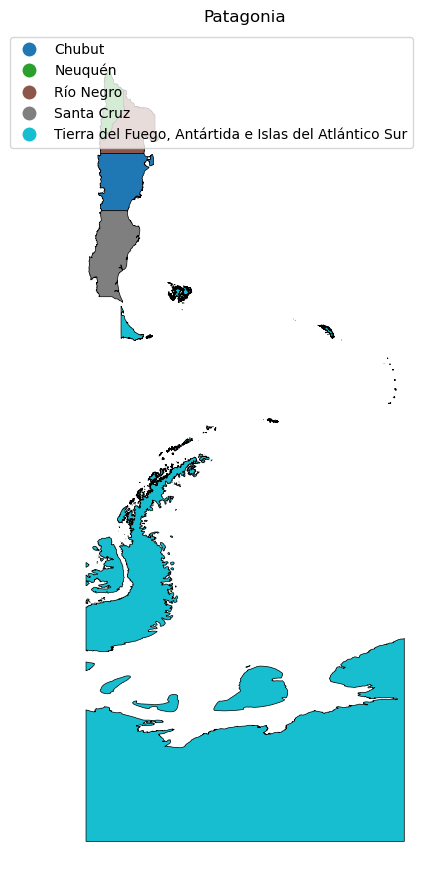

In [8]:
fig, ax = plt.subplots(figsize=(6, 9))
patagonia.plot(ax=ax, column='nam', cmap='tab10', edgecolor='black', linewidth=0.5, legend=True)
ax.set_title('Patagonia')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 6. Una provincia individual: Córdoba

Buscamos por código INDEC y combinamos geometría + metadata.

nombre: Córdoba
código INDEC: 14
ISO: AR-X
capital: Córdoba
región: Pampeana


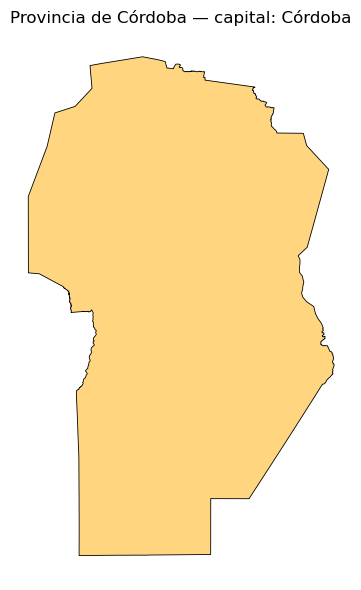

In [9]:
meta = arg.provincias.lookup('Córdoba')
print(f"nombre: {meta.nombre}")
print(f"código INDEC: {meta.codigo_indec}")
print(f"ISO: {meta.iso_id}")
print(f"capital: {meta.capital}")
print(f"región: {meta.region}")

geom = gdf[gdf['in1'] == meta.codigo_indec]

fig, ax = plt.subplots(figsize=(6, 6))
geom.plot(ax=ax, color='#FFD580', edgecolor='black', linewidth=0.6)
ax.set_title(f"Provincia de {meta.nombre} — capital: {meta.capital}")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 7. Ranking de superficie

Reproyectamos a Web Mercator (EPSG:3857) para obtener áreas en metros². El valor absoluto está distorsionado, pero el **ranking relativo** es correcto.

In [10]:
areas = gdf.copy()
areas['area_km2_aprox'] = areas.to_crs(3857).geometry.area / 1e6
areas[['nam', 'region', 'area_km2_aprox']].sort_values('area_km2_aprox', ascending=False).head(10)

/Users/tobiasyatche/miniconda3/lib/python3.10/site-packages/shapely/measurement.py:45: RuntimeWarning: invalid value encountered in area
  return lib.area(geometry, **kwargs)


,nam,region,area_km2_aprox
23,Santa Cruz,Patagonia,564333.230775
14,Buenos Aires,Pampeana,477339.718655
10,Chubut,Patagonia,430883.306998
11,Río Negro,Patagonia,349310.694506
6,Córdoba,Pampeana,230566.898633
7,La Pampa,Pampeana,225849.349327
18,Mendoza,Cuyo,220904.817565
13,Salta,NOA,187956.845426
2,Santa Fe,Pampeana,181140.233730
5,Santiago del Estero,NOA,175779.176706


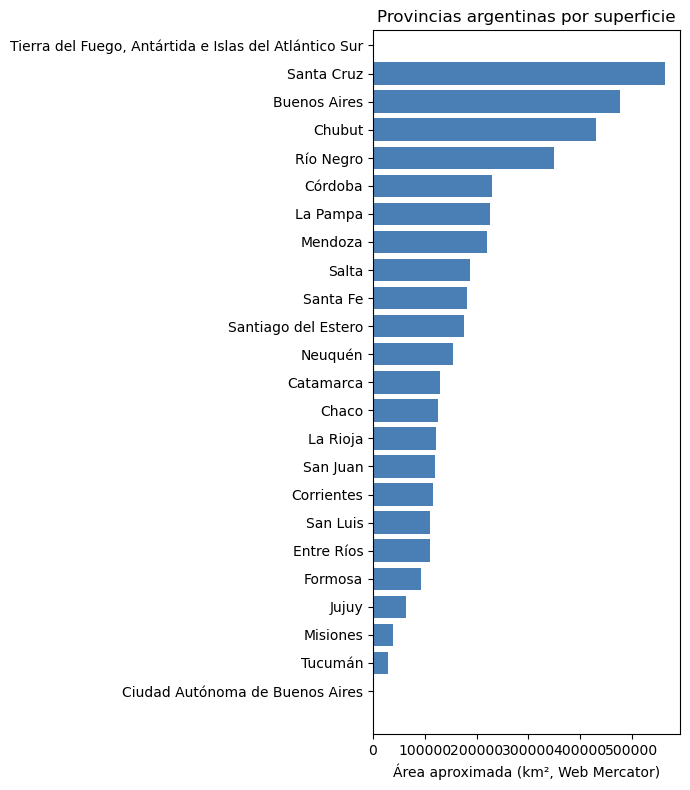

In [11]:
ranking = areas.sort_values('area_km2_aprox')

fig, ax = plt.subplots(figsize=(7, 8))
ax.barh(ranking['nam'], ranking['area_km2_aprox'], color='#4a7fb5')
ax.set_xlabel('Área aproximada (km², Web Mercator)')
ax.set_title('Provincias argentinas por superficie')
plt.tight_layout()
plt.show()

## 8. Departamentos de Buenos Aires

Bajamos la capa de departamentos (~57 MB, cacheada después de la primera vez) y zoom a los 135 partidos bonaerenses.

In [12]:
dep = arg.geo.shapes.departamentos()
ba = dep[dep['in1'].str.startswith('06')]
print(f"{len(ba)} departamentos en Buenos Aires")
ba[['in1', 'nam']].head()

135 departamentos en Buenos Aires


,in1,nam
4,06707,Saladillo
5,06455,Las Flores
6,06686,Rojas
7,06252,Escobar
8,06412,José C. Paz


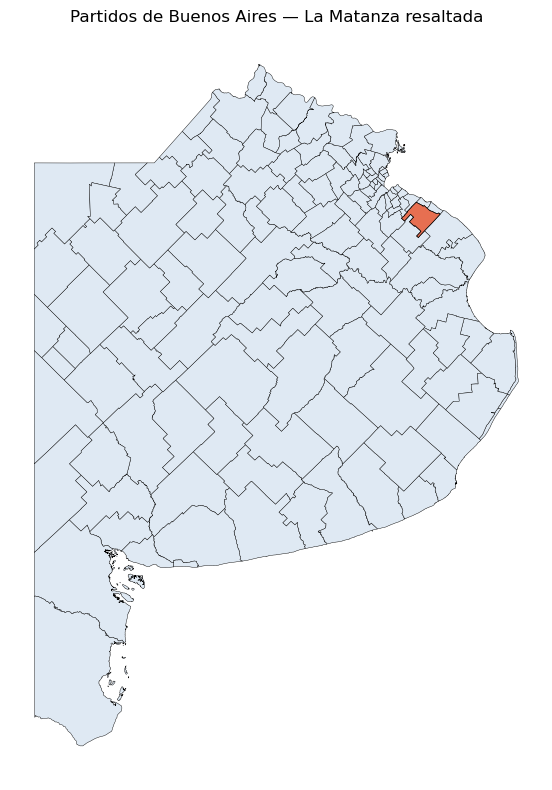

In [13]:
fig, ax = plt.subplots(figsize=(7, 8))
ba.plot(ax=ax, edgecolor='black', facecolor='#dfe9f3', linewidth=0.3)

# Resaltar La Matanza (uno de los partidos más poblados)
matanza = ba[ba['in1'] == '06441']
matanza.plot(ax=ax, color='#e76f51', edgecolor='black', linewidth=0.5)

ax.set_title('Partidos de Buenos Aires — La Matanza resaltada')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 9. Comunas de CABA

Las 15 comunas porteñas (código INDEC empieza con `02`).

15 comunas


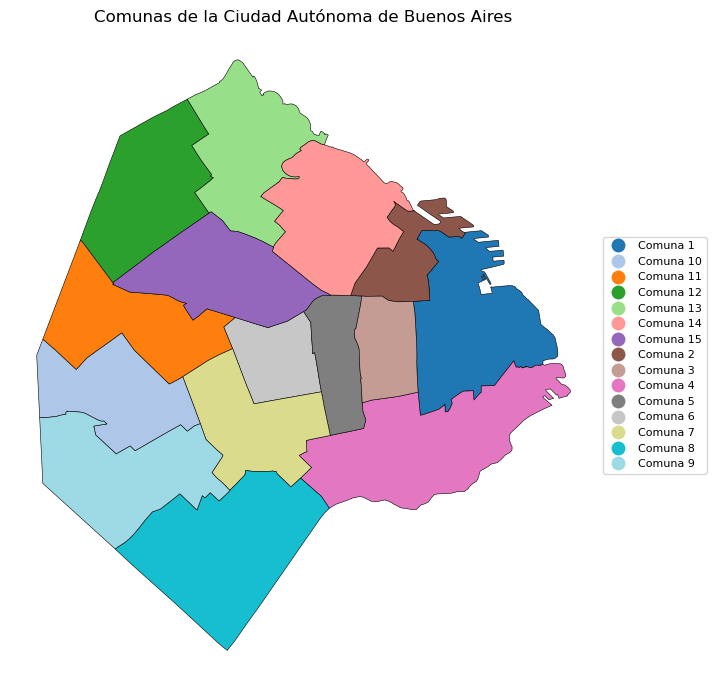

In [14]:
caba = dep[dep['in1'].str.startswith('02')]
print(f"{len(caba)} comunas")

fig, ax = plt.subplots(figsize=(7, 7))
caba.plot(ax=ax, column='nam', cmap='tab20', edgecolor='black', linewidth=0.4, legend=True,
          legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5), 'fontsize': 8})
ax.set_title('Comunas de la Ciudad Autónoma de Buenos Aires')
ax.set_axis_off()
plt.tight_layout()
plt.show()